In [38]:
import pandas as pd 
import seaborn as sns
import glob
from scipy.stats import kruskal
from scikit_posthocs import posthoc_dunn
from matplotlib import pyplot as plt

In [39]:
folder1 = r"Q:\ChromatinTeam\img_processing_t4\2020-06-15-Exp333_KSB_Elyra_DAPI_TADs_SIM_temp_brdu\Analysis\\"
folder2 = r"Q:\ChromatinTeam\img_processing_t4\2021-03-17_Exp352_KSB_elyra_SIM_RDs_analysis\\"
paths1 = glob.glob(folder1+'*.csv')
paths2 = glob.glob(folder2+'*.csv')
paths = paths1+paths2

dfs = []
for path in paths:
    df = pd.read_csv(path)
    df['sample'] = path.split('_')[-4]
    df['feature'] = path.split('_')[-2]
    dfs.append(df)
dfs = pd.concat(dfs)
dfs=dfs[dfs['PCC']>0.2]

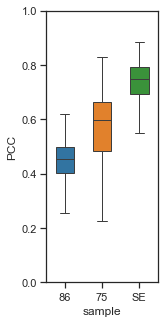

In [40]:
folder = r'C:\Users\ellenberg\Documents\Kai\Manuscripts\Chromatin_tracing_manuscript\Figures\Resources'
metric='PCC'
feature = 'nuc'
#sample_map = {'3D':'86', '5C':'75', '3D':'SE', '1D': 'SE', '2C': '75', '3C': '86'}
#dfs['sample_name'] = dfs['sample'].map(sample_map)
sel = ['86', '75', 'SE']
sns.set(rc={'figure.figsize':(2,5), 'lines.linewidth': 1})
sns.set_style("ticks")
sns.set_palette('tab10')
sns.boxplot(data=dfs[dfs['sample'].isin(sel)].query('feature == @feature').sort_values('sample', ascending=True), y=metric, x='sample', order = sel, fliersize=0, width=0.5)
plt.ylim(0,1)
plt.savefig(folder+'SIM_comp_plot_'+feature+'_'+metric+'.pdf', format='pdf', dpi=600, bbox_inches='tight', transparent=True)

In [41]:
print(posthoc_dunn(dfs.query('feature == @feature'), val_col=metric, group_col='sample'))

                75             86             SE           SEL
75    1.000000e+00   1.400177e-31  1.779112e-103  6.510870e-30
86    1.400177e-31   1.000000e+00  1.115307e-193  3.390682e-88
SE   1.779112e-103  1.115307e-193   1.000000e+00  4.787622e-09
SEL   6.510870e-30   3.390682e-88   4.787622e-09  1.000000e+00


In [42]:
dfs.groupby(['sample','feature']).count()

Unnamed: 0  label  bbox-0  bbox-1  bbox-2  bbox-3  area  \
sample feature                                                            
75     nuc             672    672     672     672     672     672   672   
       rd              804    804     804     804     804     804   804   
86     nuc             358    358     358     358     358     358   358   
       rd              382    382     382     382     382     382   382   
SE     nuc             658    658     658     658     658     658   658   
       rd              786    786     786     786     786     786   786   
SEL    nuc             309    309     309     309     309     309   309   
       rd              324    324     324     324     324     324   324   

                position   ds  zmid  zmid_o  y_f  x_f   id  MAC  PCC  SSIM  
sample feature                                                              
75     nuc           672  672   672     664  664  664  672  672  672   672  
       rd            804  804     0       0    0    0  804  804  804   804  
86     nuc           358  358   358     358  358  358  358  358  358   358  
       rd            382  382     0       0    0    0  382  382  382   382  
SE     nuc           658  658   658     658  658  658  658  658  658   658  
       rd            786  786     0       0    0    0  786  786  786   786  
SEL    nuc           309  309   309     309  309  309  309  309  309   309  
       rd            324  324     0       0    0    0  324  324  324   324